In [ ]:
import os
from zipline.data.run_ingest import simple_ingest
from zipline.sources.TEJ_Api_Data import get_universe

start_date = '2013-01-01'
end_date = '2024-12-31'

# 2. 設定我們要抓的股票清單
# 這裡我把你提供的清單複製過來，並確保 'IR0001'(大盤) 和 '2330'(台積電) 都在裡面
# 這樣策略才有股票可以買，也有大盤可以比較
pool = get_universe(start=start_date, end=end_date, mkt_bd_e='TSE',
                        stktp_e='Common Stock', main_ind_e='General Industry')
ticker_list = 'IR0001 ' + ' '.join(pool)

# 3. 設定時間範圍
# 我們回測是 2014-2024，但為了預先運算，我們多抓一年，從 2013 開始


print(f"正在下載 {len(ticker_list.split())} 檔股票資料，期間：{start_date} ~ {end_date}...")
print("這會消耗你的 API 流量，請稍候...")

# 4. 執行載入 (Ingest)
simple_ingest(
    name='tquant',
    tickers=ticker_list,
    start_date=start_date,
    end_date=end_date
)

print("資料載入完成！")

Currently used TEJ API key call quota 555/100000 (0.56%)
Currently used TEJ API key data quota 35015194/10000000 (350.15%)
正在下載 948 檔股票資料，期間：2013-01-01 ~ 2024-12-31...
這會消耗你的 API 流量，請稍候...
Now ingesting data.


[2026-02-04 08:40:46.575329] INFO: zipline.data.bundles.core: Ingesting tquant.


Merging daily equity files:


[2026-02-04 08:45:29.805329] INFO: zipline.data.bundles.core: Ingest tquant successfully.


Currently used TEJ API key call quota 561/100000 (0.56%)
Currently used TEJ API key data quota 39893774/10000000 (398.94%)
End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('2013-01-01', tz = 'utc'),end_dt = pd.Timestamp('2024-12-31' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 561/100000 (0.56%)
Currently used TEJ API key data quota 39893774/10000000 (398.94%)
資料載入完成！


## 第一階段：環境準備與資料篩選函式
這段程式碼的核心在於 `select` 函式。它的功能是：抓取每年的股價與財報資料，計算「帳面市值比 (B/M)」、「市值 (Size)」和「報酬率 (Momentum)」，並選出符合條件的股票。

注意：你需要填入你的 TEJ API Key。

In [ ]:
import os
import pandas as pd
import numpy as np
import TejToolAPI
from zipline.sources.TEJ_Api_Data import get_universe

def select(first, last, st, en, year):
    # 請在下面寫出 get_universe 的程式碼...
    pool = get_universe(start=first, end=last, mkt_bd_e='TSE',
                        stktp_e='Common Stock', main_ind_e='General Industry')

    # 2. 取得年初資料
    data_start = TejToolAPI.get_history_data(start = pd.Timestamp(st), end = pd.Timestamp(st),ticker = pool, fin_type = 'A',columns = ['收盤價', '調整係數'], transfer_to_chinese=True)

    # 3. 取得年末資料
    data_end = TejToolAPI.get_history_data(start = pd.Timestamp(en), end = pd.Timestamp(en),ticker = pool, fin_type = 'A',columns = ['收盤價', '股價淨值比', 'mktcap', '調整係數'], transfer_to_chinese=True)

    # 4. 設定 Index (把 '股票代碼' 變成索引)
    data_start.set_index('股票代碼', inplace=True)
    data_end.set_index('股票代碼', inplace=True)

    # 5. 取交集 (找出 data_start 和 data_end 都有的股票)
    coid = sorted(list(set(data_start.index) & set(data_end.index)))

    # 6. 建 DataFrame (包含你提到的 01 和 12 收盤價)
    df = pd.DataFrame({
        '股票代碼': coid,
        '01收盤價': [data_start.loc[i,'收盤價'] for i in coid],
        '12收盤價': [data_end.loc[i,'收盤價'] for i in coid],
        'Return': [(data_end.loc[i,'收盤價'] * data_end.loc[i,'調整係數']) / (data_start.loc[i,'收盤價'] * data_start.loc[i,'調整係數']) - 1 for i in coid],
        'pb':     [data_end.loc[i,'股價淨值比']for i in coid],
        'bm':     [1/data_end.loc[i,'股價淨值比']for i in coid],
        'mkt':    [data_end.loc[i,'個股市值_元'] for i in coid]
    })

    # 7. 篩選函式
    def filter_stocks(percent1, percent2):
        # 算出要選幾檔 (總數的 percent %)
        n1 = int(len(df) * percent1 / 100)
        n2 = int(len(df) * percent2 / 100)

        # 1. 規模因子：找 mkt 最小的前 n1 名
        df_mv = df.nsmallest(n1, 'mkt')['股票代碼']

        # 2. 價值因子：找 bm 最大的前 n1 名 (請填寫)
        df_bm = df.nlargest(n1, 'bm')['股票代碼']

        # 3. 動量因子：找 Return 最大的前 n2 名 (請填寫)
        df_ret = df.nlargest(n2, 'Return')['股票代碼']

        # 4. 取交集 (同時符合這三個條件)
        selected = sorted(list(set(df_mv) & set(df_bm) & set(df_ret)))

        print(f"篩選出 {len(selected)} 間公司")
        return selected

    # 執行篩選
    selected = filter_stocks(30, 30)
    return selected


## 第二階段：Zipline 回測架構
這裡定義了策略如何執行。

* `initialize`: 程式啟動時執行一次。這裡它很聰明地預先跑完所有年份的選股 (`context.yearly_stocks`)，這樣回測時速度會比較快。

* `handle_data`: 每天執行一次。判斷是否為「年初」(買入) 或 「年末」(賣出)。

In [ ]:
from zipline.api import *
from zipline.finance import commission, slippage
import matplotlib.pyplot as plt

def initialize(context):
    years = range(2013, 2025)
    context.yearly_stocks = {}
    context.buy_flags = {year: False for year in years}
    context.sell_flags = {year: False for year in years}

    # === 1. 先定義好日期表 (移到最上面！) ===
    # 這樣我們才能在選股時知道哪一天有開盤
    context.first_trading_days = {
        2013: pd.Timestamp('2013-01-02').date(),
        2014: pd.Timestamp('2014-01-02').date(),
        2015: pd.Timestamp('2015-01-05').date(),
        2016: pd.Timestamp('2016-01-04').date(),
        2017: pd.Timestamp('2017-01-03').date(),
        2018: pd.Timestamp('2018-01-02').date(),
        2019: pd.Timestamp('2019-01-02').date(),
        2020: pd.Timestamp('2020-01-02').date(),
        2021: pd.Timestamp('2021-01-04').date(),
        2022: pd.Timestamp('2022-01-03').date(),
        2023: pd.Timestamp('2023-01-03').date(),
        2024: pd.Timestamp('2024-01-02').date()
    }

    context.last_trading_days = {
        2013: pd.Timestamp('2013-12-31').date(),
        2014: pd.Timestamp('2014-12-31').date(),
        2015: pd.Timestamp('2015-12-31').date(),
        2016: pd.Timestamp('2016-12-30').date(),
        2017: pd.Timestamp('2017-12-29').date(),
        2018: pd.Timestamp('2018-12-28').date(),
        2019: pd.Timestamp('2019-12-31').date(),
        2020: pd.Timestamp('2020-12-31').date(),
        2021: pd.Timestamp('2021-12-30').date(),
        2022: pd.Timestamp('2022-12-30').date(),
        2023: pd.Timestamp('2023-12-29').date(),
        2024: pd.Timestamp('2024-12-31').date()
    }

    # === 2. 成本設定 ===
    set_slippage(slippage.VolumeShareSlippage(volume_limit=0.025, price_impact=0.1))
    set_commission(commission.Custom_TW_Commission(min_trade_cost=20, discount=1.0, tax=0.003))
    set_benchmark(symbol('IR0001'))
    # === 3. 開始選股 ===
    print("開始預先計算每年選股名單...")

    # 注意：我們雖然回測 years (2013~2024)，但選股要用「前一年」的數據
    # 如果 years 從 2013 開始，那我們第一年(2013)其實沒辦法根據「前一年(2012)」選股
    # 因為你的日期字典裡沒有 2012。

    # 策略調整：
    # 我們假設 2014 年買入的是「根據 2013 年數據篩選出」的股票
    # 所以 years 迴圈代表的是「交易執行年」

    for year in years:
        # 如果是 2013 年，因為沒有 2012 的資料，我們跳過不買，或者你可以手動補充 2012 的日期
        if year == 2013:
            context.yearly_stocks[year] = []
            continue

        prev_year = year - 1  # 關鍵修正：使用前一年

        # 設定搜尋範圍 (用前一年的整年)
        range_start = f"{prev_year}-01-01"
        range_end   = f"{prev_year}-12-31"

        # 設定精確抓價日 (用前一年的開盤與收盤)
        # 這樣選出來的股票，就是 prev_year 的強勢股或價值股
        exact_start = context.first_trading_days[prev_year].strftime('%Y-%m-%d')
        exact_end   = context.last_trading_days[prev_year].strftime('%Y-%m-%d')

        # 呼叫 select (用前一年的數據)
        selected_tickers = select(range_start, range_end, exact_start, exact_end, prev_year)

        # 將選出的名單，存入「今年(year)」的欄位
        # 意思：2014 年要買的股票 = 2013 年篩選出來的結果
        context.yearly_stocks[year] = selected_tickers

        print(f"已計算 {year} 年投資組合 (基於 {prev_year} 數據)")

def handle_data(context, data):
    # 1. 取得今天日期
    current_date = get_datetime().date()
    current_year = current_date.year

    # 2. 買入邏輯：如果是年初首個交易日 且 沒買過
    # (請參考上面的提示寫出 if 判斷式)
    if current_year in context.first_trading_days and \
       current_date == context.first_trading_days[current_year] and \
       not context.buy_flags[current_year]:

        # 3. 取出當年度要買的股票名單
        # 注意：我們是用「去年」的數據選股，來決定「今年」買什麼
        # 所以這裡要拿 context.yearly_stocks[current_year]
        # (原本邏輯是用 current_year 選出的股在 current_year 買，依照你的 select 寫法)
        tickers = context.yearly_stocks.get(current_year, [])

        # 檢查哪些股票今天還活著 (沒下市、沒停牌)
        tradable = [tk for tk in tickers if data.can_trade(symbol(tk))]

        if tradable:
            # 資金平分
            equal_weight = 0.95 / len(tradable)

            # 下單(再平衡常用的 order_target_percent)
            for ticker in tradable:
                order_target_percent(symbol(ticker), equal_weight)

            # 4. 記得打勾，表示今年買過了
            context.buy_flags[current_year] = True
            print(f"{current_date}: 年初買入 {len(tradable)} 檔")

    # --- 賣出邏輯 ---
    # 檢查：是最後交易日 且 沒賣過
    elif current_year in context.last_trading_days and \
         current_date == context.last_trading_days[current_year] and \
         not context.sell_flags[current_year]:

        # 遍歷目前持倉，全部設為 0% (清倉)
        for stock in context.portfolio.positions:
            order_target_percent(stock, 0)

        context.sell_flags[current_year] = True
        print(f"清倉: {current_date}")



def analyze(context, results):
    # 1. 設定畫布大小
    plt.figure(figsize=(18, 8))

    # 2. 畫圖 (關鍵！)
    # 請從 results 表格中，抓出 'portfolio_value' 欄位，並呼叫 .plot()
    # 提示：寫法像 results['欄位名'].plot(...)
    ax = plt.subplot(111)
    results['portfolio_value'].plot(ax=ax, label='Strategy')

    # 3. 裝飾圖表
    ax.set_ylabel('Portfolio Value (TWD)')
    ax.set_title('Three-Factor Strategy Backtest Result')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

## 第三階段：執行回測 (Run Algorithm)

這是啟動引擎的鑰匙。設定好資金、日期，然後開跑。

開始執行回測...
開始預先計算每年選股名單...
Currently used TEJ API key call quota 938/100000 (0.94%)
Currently used TEJ API key data quota 42052364/10000000 (420.52%)
Currently used TEJ API key call quota 989/100000 (0.99%)
Currently used TEJ API key data quota 42241712/10000000 (422.42%)
Currently used TEJ API key call quota 1040/100000 (1.04%)
Currently used TEJ API key data quota 42432956/10000000 (424.33%)
篩選出 15 間公司
已計算 2014 年投資組合 (基於 2013 數據)
Currently used TEJ API key call quota 1041/100000 (1.04%)
Currently used TEJ API key data quota 42624401/10000000 (426.24%)
Currently used TEJ API key call quota 1092/100000 (1.09%)
Currently used TEJ API key data quota 42815089/10000000 (428.15%)
Currently used TEJ API key call quota 1143/100000 (1.14%)
Currently used TEJ API key data quota 43013332/10000000 (430.13%)
篩選出 18 間公司
已計算 2015 年投資組合 (基於 2014 數據)
Currently used TEJ API key call quota 1144/100000 (1.14%)
Currently used TEJ API key data quota 43204336/10000000 (432.04%)
Currently used TEJ API key cal

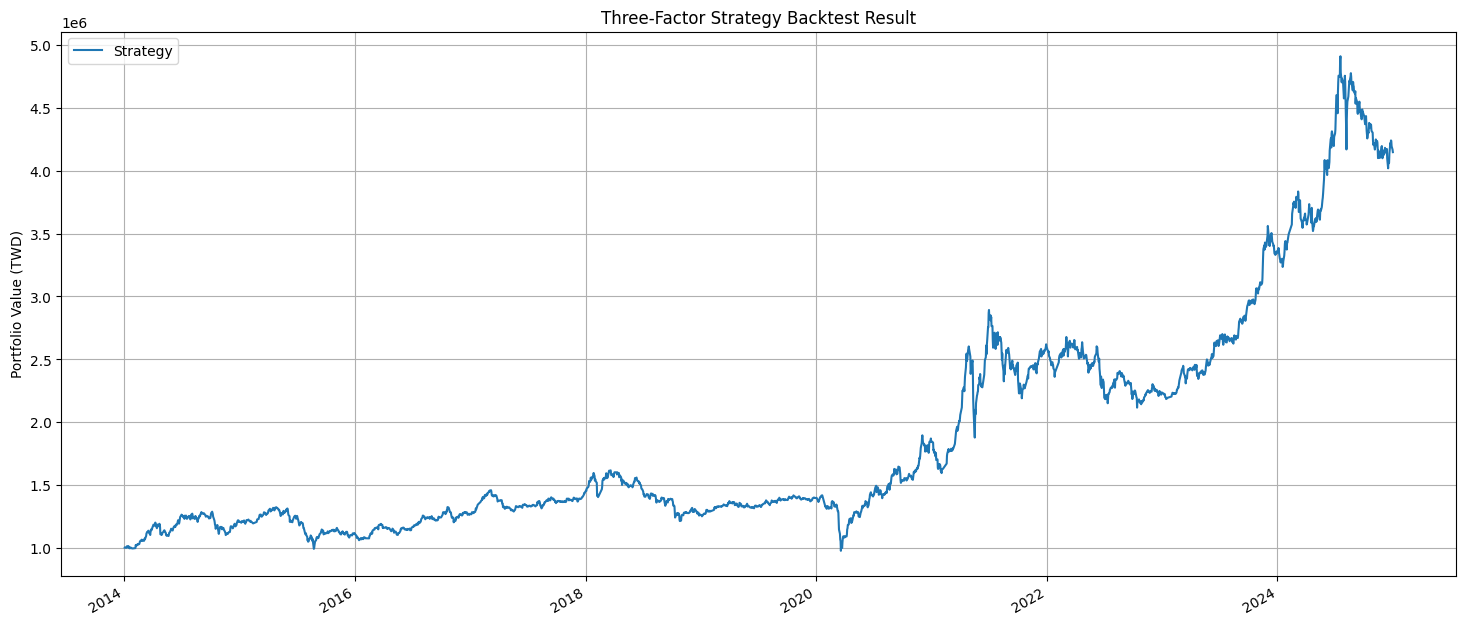

回測完成！


In [ ]:
from zipline import run_algorithm

# 設定回測區間
start_dt = pd.Timestamp('2014-01-01', tz='utc')
end_dt   = pd.Timestamp('2024-12-31', tz='utc')
capital  = 1e6  # 起始資金 100 萬

print("開始執行回測...")

results = run_algorithm(
    start=start_dt,
    end=end_dt,
    initialize=initialize,
    handle_data=handle_data,
    analyze=analyze,
    bundle='tquant',  # 這是 TEJ 專用的資料包名稱
    capital_base=capital
)
print("回測完成！")

## 第四階段：績效分析 (Pyfolio)
回測跑完後，results 變數裡存了所有數據，這時候用 Pyfolio 來產生專業報表。

------ 大盤績效指標 ------


Start date,2014-01-02
End date,2024-12-31
Total months,127
,Backtest
Annual return,13.887%
Cumulative returns,300.08%
Annual volatility,15.678%
Sharpe ratio,0.91
Calmar ratio,0.49
Stability,0.93
Max drawdown,-28.553%


Start date,2014-01-02
End date,2024-12-31
Total months,127
,Backtest
Annual return,14.273%
Cumulative returns,314.809%
Annual volatility,18.762%
Sharpe ratio,0.81
Calmar ratio,0.36
Stability,0.80
Max drawdown,-39.631%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,39.63,2018-03-21,2020-03-19,2020-09-04,604
1,27.88,2021-04-28,2021-05-17,2021-06-22,38
2,26.88,2021-07-01,2022-10-13,2023-09-25,547
3,25.02,2015-04-27,2015-08-24,2016-10-20,366
4,18.16,2024-07-18,2024-12-16,NaT,NaN


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

Top 10 long positions of all time,max
sid,
2365,26.81%
2543,20.05%
3050,19.64%
3024,18.52%
2611,18.04%
6152,16.89%
1474,16.70%
1452,16.38%
4930,15.83%


Top 10 short positions of all time,max
sid,
3050,-4.16%


Top 10 positions of all time,max
sid,
2365,26.81%
2543,20.05%
3050,19.64%
3024,18.52%
2611,18.04%
6152,16.89%
1474,16.70%
1452,16.38%
4930,15.83%


findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

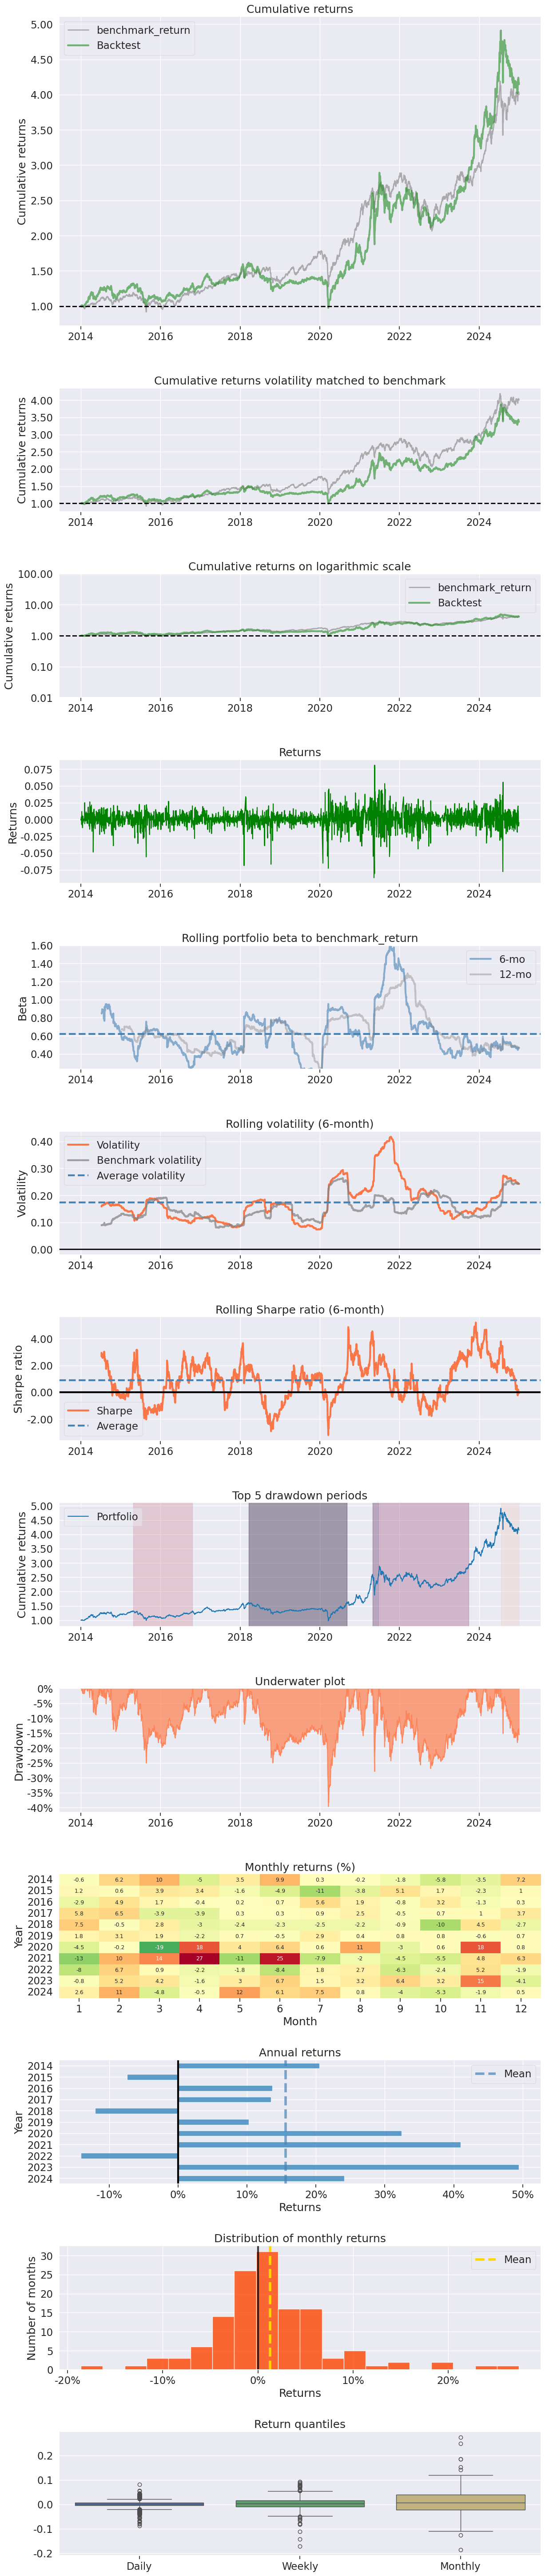

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

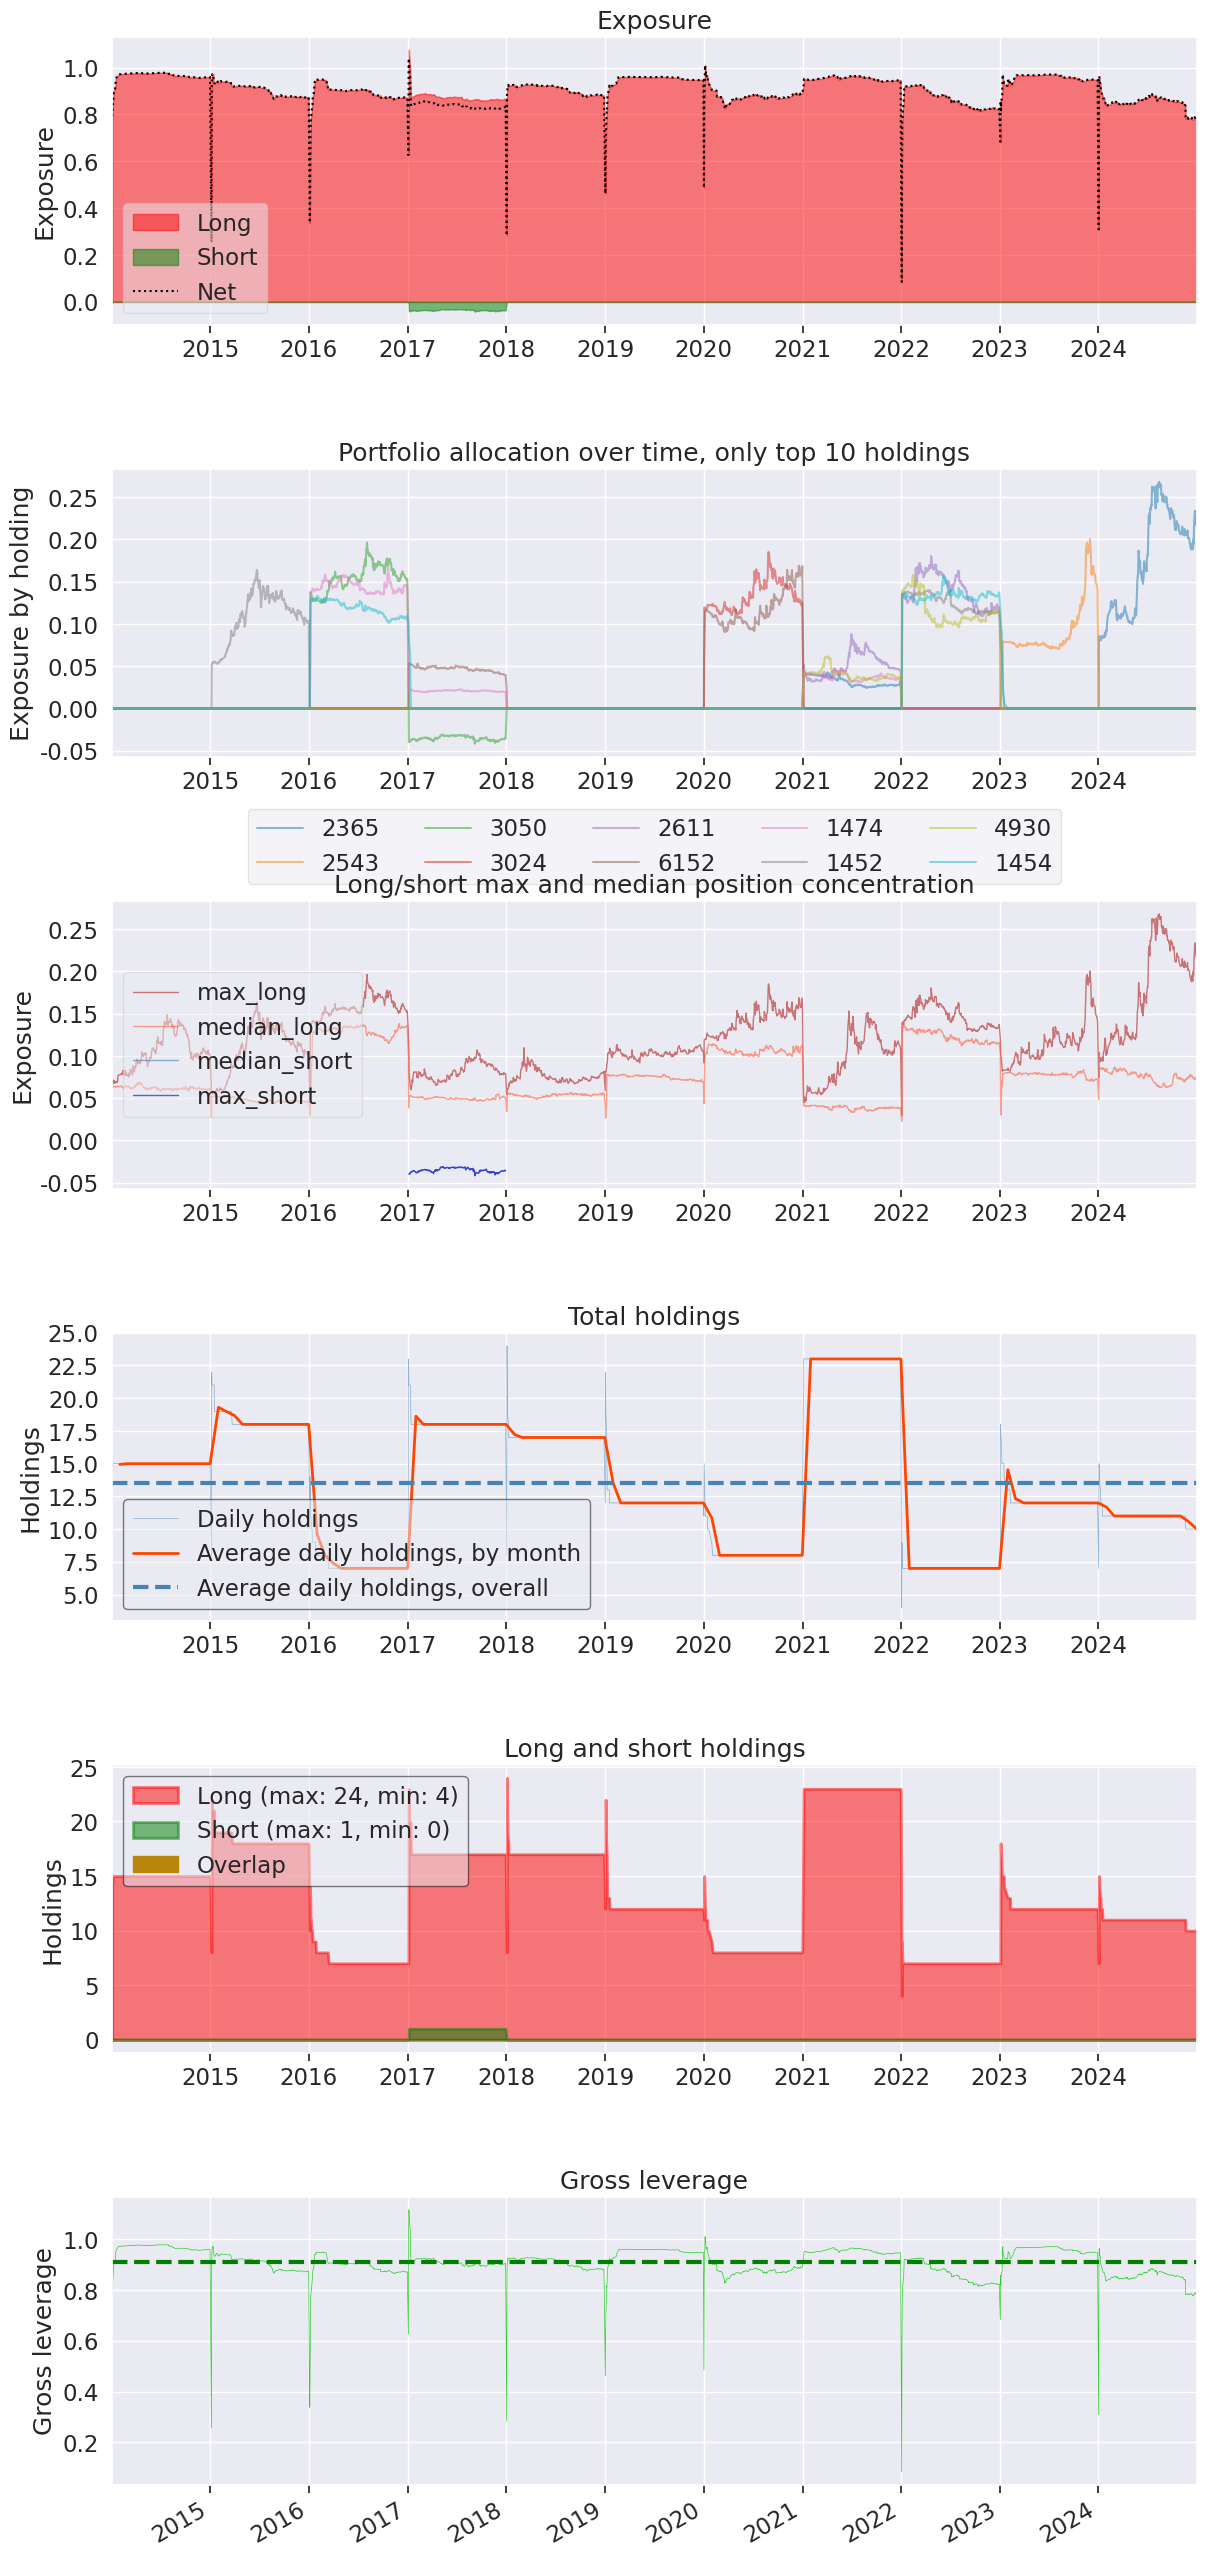

findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

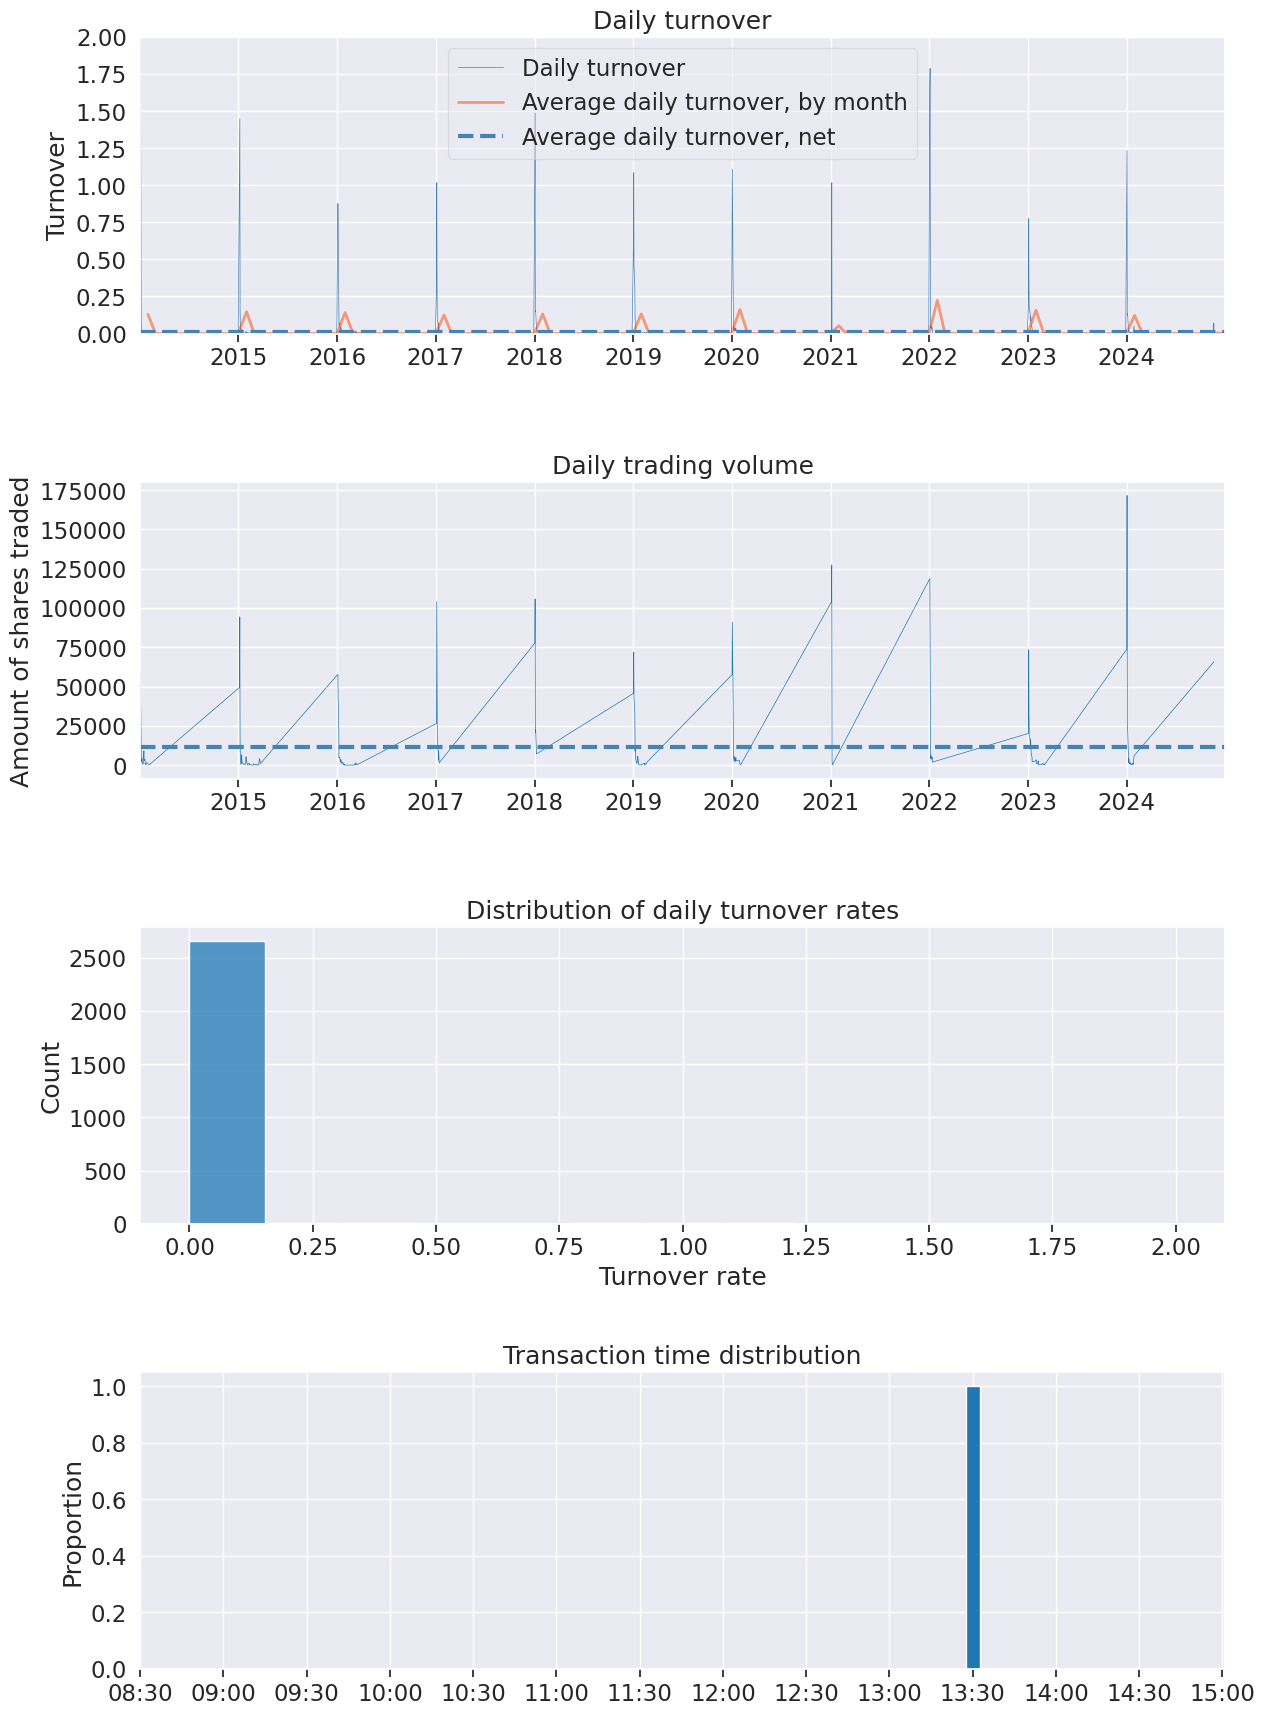

In [ ]:
import pyfolio as pf
from pyfolio.utils import extract_rets_pos_txn_from_zipline

# 從 zipline 結果中提取 returns, positions, transactions
returns, positions, transactions = extract_rets_pos_txn_from_zipline(results)
benchmark_rets = results.benchmark_return

print("------ 大盤績效指標 ------")
pf.show_perf_stats(benchmark_rets)
# 產生全方位報表 (Tear Sheet)
pf.tears.create_full_tear_sheet(
    returns=returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_rets
)